# Pandas and Visualisation Recap
This notebook gives you a refresh on the pandas essentials needed for ML and data science workflows.

We focus on:
- Inspecting & understanding data  
- Accessing rows/columns  
- Cleaning & preprocessing  
- Joining  
- Groupby  
- Feature engineering  

---

## 1. Reading and Inspecting Data

- `pd.read_csv()` / `read_excel()`
- `.head()`, `.info()`, `.describe()`
- Checking dtypes and spotting object-vs-int issues

In [1]:
import pandas as pd

In [5]:
titanic = pd.read_csv("data/titanic.csv")
titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,home.dest,body,boat
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,"St Louis, MO",NaN,2
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",NaN,11
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",NaN,NaN
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",135.0,NaN
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",NaN,NaN


In [6]:
titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,home.dest,body,boat
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,"St Louis, MO",NaN,2
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",NaN,11
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",NaN,NaN
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",135.0,NaN
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",NaN,NaN


In [ ]:
titanic.tail(10) # Shows the last 10 rows of the dataset

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,home.dest,body,boat
1300,3.0,1.0,"Yasbeck, Mrs. Antoni (Selini Alexander)",female,15.0,1.0,0.0,2659,14.4542,NaN,C,NaN,NaN,NaN
1301,3.0,0.0,"Youseff, Mr. Gerious",male,45.5,0.0,0.0,2628,7.2250,NaN,C,NaN,312.0,NaN
1302,3.0,0.0,"Yousif, Mr. Wazli",male,NaN,0.0,0.0,2647,7.2250,NaN,C,NaN,NaN,NaN
1303,3.0,0.0,"Yousseff, Mr. Gerious",male,NaN,0.0,0.0,2627,14.4583,NaN,C,NaN,NaN,NaN
1304,3.0,0.0,"Zabour, Miss. Hileni",female,14.5,1.0,0.0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3.0,0.0,"Zabour, Miss. Thamine",female,NaN,1.0,0.0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3.0,0.0,"Zakarian, Mr. Mapriededer",male,26.5,0.0,0.0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3.0,0.0,"Zakarian, Mr. Ortin",male,27.0,0.0,0.0,2670,7.2250,NaN,C,NaN,NaN,NaN
1308,3.0,0.0,"Zimmerman, Mr. Leo",male,29.0,0.0,0.0,315082,7.8750,NaN,S,NaN,NaN,NaN
1309,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1310 entries, 0 to 1309
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   float64
 1   survived   1309 non-null   float64
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   float64
 6   parch      1309 non-null   float64
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  home.dest  745 non-null    object 
 12  body       121 non-null    float64
 13  boat       486 non-null    object 
dtypes: float64(7), object(7)
memory usage: 143.4+ KB


Do all object types look as they should?
- survived could be bool?
- parent children could be int.

In [8]:
titanic.describe()

,pclass,survived,age,sibsp,parch,fare,body
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,0.381971,29.881135,0.498854,0.385027,33.295479,160.809917
std,0.837836,0.486055,14.413500,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.000000,0.166700,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200,328.000000


In [ ]:
titanic['age'].describe() # just want age information

count    1046.000000
mean       29.881135
std        14.413500
min         0.166700
25%        21.000000
50%        28.000000
75%        39.000000
max        80.000000
Name: age, dtype: float64

In [9]:
titanic.dtypes

pclass       float64
survived     float64
name          object
sex           object
age          float64
sibsp        float64
parch        float64
ticket        object
fare         float64
cabin         object
embarked      object
home.dest     object
body         float64
boat          object
dtype: object

In [ ]:
titanic.isna().sum() # Useful for checking how many missing values there are in each column

pclass          1
survived        1
name            1
sex             1
age           264
sibsp           1
parch           1
ticket          1
fare            2
cabin        1015
embarked        3
home.dest     565
body         1189
boat          824
dtype: int64

### Task
- Load the dataset animals.csv.

- Show the first 5 rows.

- Check the dtypes.

- Identify any problems (object columns that should be numeric/datetime).

In [19]:
# Load the dataset
animals = pd.read_csv("data/animals.csv")

# Show the first 5 rows
animals.head(5)

,IncidentNumber,DateTimeOfCall,CalYear,FinYear,TypeOfIncident,PumpCount,PumpHoursTotal,HourlyNominalCost(£),IncidentNominalCost(£),FinalDescription,AnimalGroupParent,PropertyType,SpecialServiceTypeCategory,SpecialServiceType,Borough,StnGroundName,AnimalClass,Code,London
0,139091,01/01/2009 03:01,2009,2008/09,Special Service,1.0,2.0,255,510.0,"DOG WITH JAW TRAPPED IN MAGAZINE RACK,B15",Dog,House - single occupancy,Other animal assistance,Animal assistance involving livestock - Other ...,Croydon,Norbury,Mammal,00AH,Outer London
1,275091,01/01/2009 08:51,2009,2008/09,Special Service,1.0,1.0,255,255.0,"ASSIST RSPCA WITH FOX TRAPPED,B15",Fox,Railings,Other animal assistance,Animal assistance involving livestock - Other ...,Croydon,Woodside,Mammal,00AH,Outer London
2,2075091,04/01/2009 10:07,2009,2008/09,Special Service,1.0,1.0,255,255.0,"DOG CAUGHT IN DRAIN,B15",Dog,Pipe or drain,Animal rescue from below ground,Animal rescue from below ground - Domestic pet,Sutton,Wallington,Mammal,00BF,Outer London
3,2872091,05/01/2009 12:27,2009,2008/09,Special Service,1.0,1.0,255,255.0,"HORSE TRAPPED IN LAKE,J17",Horse,"Intensive Farming Sheds (chickens, pigs etc)",Animal rescue from water,Animal rescue from water - Farm animal,Hillingdon,Ruislip,Mammal,00AS,Outer London
4,3553091,06/01/2009 15:23,2009,2008/09,Special Service,1.0,1.0,255,255.0,"RABBIT TRAPPED UNDER SOFA,B15",Rabbit,House - single occupancy,Other animal assistance,Animal assistance involving livestock - Other ...,Havering,Harold Hill,Mammal,00AR,Outer London


In [21]:
# Check dtypes
animals.dtypes

IncidentNumber                 object
DateTimeOfCall                 object
CalYear                         int64
FinYear                        object
TypeOfIncident                 object
PumpCount                     float64
PumpHoursTotal                float64
HourlyNominalCost(£)            int64
IncidentNominalCost(£)        float64
FinalDescription               object
AnimalGroupParent              object
PropertyType                   object
SpecialServiceTypeCategory     object
SpecialServiceType             object
Borough                        object
StnGroundName                  object
AnimalClass                    object
Code                           object
London                         object
dtype: object

In [23]:
animals.describe()

,CalYear,PumpCount,PumpHoursTotal,HourlyNominalCost(£),IncidentNominalCost(£)
count,5752.000000,5716.000000,5716.000000,5752.000000,5716.000000
mean,2013.378651,1.022393,1.185269,288.390647,341.723233
std,2.831969,0.162619,0.660178,28.439044,194.099991
min,2009.000000,1.000000,1.000000,255.000000,255.000000
25%,2011.000000,1.000000,1.000000,260.000000,260.000000
50%,2013.000000,1.000000,1.000000,290.000000,295.000000
75%,2016.000000,1.000000,1.000000,326.000000,328.000000
max,2018.000000,4.000000,12.000000,333.000000,3912.000000


**Problems Identified**
- incident number should be int
- DateTimeOfCall should be datetime
- IncidentNominalCost should be int?

## 2. Selecting Data: loc, iloc, boolean filters

`.loc` - label-based

`.iloc` - position-based

Boolean filters are essential for feature engineering and cleaning.

In [26]:
# Rows where value > 50
titanic.loc[titanic["age"] > 50]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,home.dest,body,boat
6,1.0,1.0,"Andrews, Miss. Kornelia Theodosia",female,63.0,1.0,0.0,13502,77.9583,D7,S,"Hudson, NY",NaN,10
8,1.0,1.0,"Appleton, Mrs. Edward Dale (Charlotte Lamson)",female,53.0,2.0,0.0,11769,51.4792,C101,S,"Bayside, Queens, NY",NaN,D
9,1.0,0.0,"Artagaveytia, Mr. Ramon",male,71.0,0.0,0.0,PC 17609,49.5042,NaN,C,"Montevideo, Uruguay",22.0,NaN
14,1.0,1.0,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0.0,0.0,27042,30.0000,A23,S,"Hessle, Yorks",NaN,B
33,1.0,1.0,"Bonnell, Miss. Elizabeth",female,58.0,0.0,0.0,113783,26.5500,C103,S,"Birkdale, England Cleveland, Ohio",NaN,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1068,3.0,0.0,"Nysveen, Mr. Johan Hansen",male,61.0,0.0,0.0,345364,6.2375,NaN,S,NaN,NaN,NaN
1225,3.0,0.0,"Storey, Mr. Thomas",male,60.5,0.0,0.0,3701,NaN,NaN,S,NaN,261.0,NaN
1235,3.0,0.0,"Svensson, Mr. Johan",male,74.0,0.0,0.0,347060,7.7750,NaN,S,NaN,NaN,NaN
1261,3.0,1.0,"Turkula, Mrs. (Hedwig)",female,63.0,0.0,0.0,4134,9.5875,NaN,S,NaN,NaN,15


In [27]:
# Using loc
titanic.loc[titanic["sex"] == "female"]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,home.dest,body,boat
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0,0.0,0.0,24160,211.3375,B5,S,"St Louis, MO",NaN,2
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2.0,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",NaN,NaN
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",NaN,NaN
6,1.0,1.0,"Andrews, Miss. Kornelia Theodosia",female,63.0,1.0,0.0,13502,77.9583,D7,S,"Hudson, NY",NaN,10
8,1.0,1.0,"Appleton, Mrs. Edward Dale (Charlotte Lamson)",female,53.0,2.0,0.0,11769,51.4792,C101,S,"Bayside, Queens, NY",NaN,D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1286,3.0,1.0,"Whabee, Mrs. George Joseph (Shawneene Abi-Saab)",female,38.0,0.0,0.0,2688,7.2292,NaN,C,NaN,NaN,C
1290,3.0,1.0,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1.0,0.0,363272,7.0000,NaN,S,NaN,NaN,NaN
1300,3.0,1.0,"Yasbeck, Mrs. Antoni (Selini Alexander)",female,15.0,1.0,0.0,2659,14.4542,NaN,C,NaN,NaN,NaN
1304,3.0,0.0,"Zabour, Miss. Hileni",female,14.5,1.0,0.0,2665,14.4542,NaN,C,NaN,328.0,NaN


In [ ]:
# Using iloc
titanic.iloc[0:2] # Using iloc to select the first 2 rows

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,home.dest,body,boat
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,"St Louis, MO",NaN,2
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",NaN,11


In [ ]:
titanic.iloc[0:3, 0:4] # Using iloc to select the first 3 rows and the first 4 columns

,pclass,survived,name,sex
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female
1,1.0,1.0,"Allison, Master. Hudson Trevor",male
2,1.0,0.0,"Allison, Miss. Helen Loraine",female


### Task
- Select all incidents where PumpCount is greater than 1.

- Using loc, show IncidentNumber, AnimalGroupParent, and Borough for incidents involving "Cat".

- Using iloc, return rows 20–40 and the first 4 columns.

In [ ]:
# My answers
# Select all incidents where PumpCount is greater than 1.
animals.loc[animals["PumpCount"] > 1]

,IncidentNumber,DateTimeOfCall,CalYear,FinYear,TypeOfIncident,PumpCount,PumpHoursTotal,HourlyNominalCost(£),IncidentNominalCost(£),FinalDescription,AnimalGroupParent,PropertyType,SpecialServiceTypeCategory,SpecialServiceType,Borough,StnGroundName,AnimalClass,Code,London
26,6970091,11/01/2009 10:11,2009,2008/09,Special Service,2.0,3.0,255,765.0,"DOG STUCK IN LAKE,J15",Dog,Lake/pond/reservoir,Animal rescue from water,Animal rescue from water - Domestic pet,Westminster,Kensington,Mammal,00BK,Inner London
37,12451091,21/01/2009 10:33,2009,2008/09,Special Service,2.0,3.0,255,765.0,"ASSIST RSPCA WITH RESCUING FOX, J15",Fox,Beach,Animal rescue from water,Wild animal rescue from water or mud,Lambeth,Lambeth,Mammal,00AY,Inner London
43,14691091,25/01/2009 12:11,2009,2008/09,Special Service,2.0,3.0,255,765.0,"DOG IN CANAL,J15",Dog,River/canal,Animal rescue from water,Animal rescue from water - Domestic pet,Hounslow,Heston,Mammal,00AT,Outer London
59,21166091,06/02/2009 09:08,2009,2008/09,Special Service,2.0,3.0,255,765.0,"DOG IN LAKE,J15",Dog,Lake/pond/reservoir,Animal rescue from water,Animal rescue from water - Domestic pet,Epping Forest,Essex,Mammal,NaN,Inner London
70,27805091,17/02/2009 13:23,2009,2008/09,Special Service,2.0,5.0,255,1275.0,"KITTEN STUCK IN MUD,J15",Cat,River/canal,Animal rescue from water,Animal rescue from water - Domestic pet,Bexley,Erith,Mammal,00AD,Outer London
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5568,092389-09072018,09/07/2018 08:35,2018,2018/19,Special Service,2.0,8.0,333,2664.0,HORSE TRAPPED IN DOORWAY ADDITIONAL FRU REQUES...,Horse,Animal harm outdoors,Other animal assistance,Animal assistance - Lift heavy domestic animal,Hillingdon,Hillingdon,Mammal,00AS,Outer London
5591,098400-17072018,17/07/2018 16:16,2018,2018/19,Special Service,2.0,5.0,333,1665.0,PUPPY TRAPPED BETWEEN TWO HOUSES FRU REQ FROM...,Dog,House - single occupancy,Other animal assistance,Assist trapped domestic animal,Enfield,Edmonton,Mammal,00AK,Inner London
5613,103432-24072018,24/07/2018 15:25,2018,2018/19,Special Service,2.0,4.0,333,1332.0,ASSIST RSPCA WITH BIRD TRAPPED IN NETTING IN P...,Bird,Lake/pond/reservoir,Animal rescue from water,Animal rescue from water - Bird,Bromley,Sidcup,Bird,00AF,Outer London
5636,108578-31072018,31/07/2018 14:39,2018,2018/19,Special Service,2.0,3.0,333,999.0,TRAPPED BLACK BIRD - 9M LADDER X 1 REQUESTED ...,Bird,House - single occupancy,Animal rescue from height,Animal rescue from height - Bird,Camden,West Hampstead,Bird,00AG,Outer London


In [35]:
# Using loc, show IncidentNumber, AnimalGroupParent, and Borough for incidents involving "Cat".
animals.loc[animals["AnimalGroupParent"] == "Cat", ["IncidentNumber", "AnimalGroupParent", "Borough"]]

,IncidentNumber,AnimalGroupParent,Borough
10,5186091,Cat,Bromley
14,5724091,Cat,Richmond Upon Thames
15,5770091,Cat,Croydon
16,5789091,Cat,Lewisham
20,6317091,Cat,Southwark
...,...,...,...
5744,137789-27092018,Cat,Hammersmith And Fulham
5747,138718-29092018,Cat,Hammersmith And Fulham
5748,138738-29092018,Cat,Waltham Forest
5749,138800-29092018,Cat,Bromley


In [36]:
# Using iloc, return rows 20–40 and the first 4 columns.
animals.iloc[20:41, 0:4]

,IncidentNumber,DateTimeOfCall,CalYear,FinYear
20,6317091,10/01/2009 11:27,2009,2008/09
21,6353091,10/01/2009 12:26,2009,2008/09
22,6355091,10/01/2009 12:32,2009,2008/09
23,6378091,10/01/2009 13:05,2009,2008/09
24,6400091,10/01/2009 13:28,2009,2008/09
25,6530091,10/01/2009 16:38,2009,2008/09
26,6970091,11/01/2009 10:11,2009,2008/09
27,7051091,11/01/2009 12:32,2009,2008/09
28,7613091,12/01/2009 13:10,2009,2008/09
29,7720091,12/01/2009 16:39,2009,2008/09


## 3. Cleaning & Preprocessing
Common operations:
- Handling missing values
- Fixing dtypes
- String cleaning
- Converting to datetime (if present)

In [38]:
# Fill missing ages
titanic["age"] = titanic["age"].fillna(titanic["age"].median())

# Fill missing Embarked values
titanic["embarked"] = titanic["embarked"].fillna(titanic["embarked"].mode()[0])

# Standardise strings
titanic["name"] = titanic["name"].str.lower()


### Tasks
- Fill missing PumpHoursTotal values with the median.
- Convert Borough to title case and strip whitespace
- Ensure AnimalGroupParent is lowercase (for consistency).

In [55]:
# Fill missing PumpHoursTotal values with the median.
animals["PumpHoursTotal"] = animals["PumpHoursTotal"].fillna(animals["PumpHoursTotal"].median())
animals["PumpHoursTotal"]

0       2.0
1       1.0
2       1.0
3       1.0
4       1.0
       ... 
5747    1.0
5748    1.0
5749    1.0
5750    1.0
5751    1.0
Name: PumpHoursTotal, Length: 5752, dtype: float64

In [56]:
# Ensure AnimalGroupParent is lowercase (for consistency).
animals["AnimalGroupParent"] = animals["AnimalGroupParent"].str.lower()
animals["AnimalGroupParent"]

0          dog
1          fox
2          dog
3        horse
4       rabbit
         ...  
5747       cat
5748       cat
5749       cat
5750       dog
5751       cat
Name: AnimalGroupParent, Length: 5752, dtype: object

In [52]:
# Convert Borough to title case and strip whitespace
animals["Borough"] = animals["Borough"].str.title().str.strip()
# Check the cleaned dataset
animals["Borough"]

0                      Croydon
1                      Croydon
2                       Sutton
3                   Hillingdon
4                     Havering
                 ...          
5747    Hammersmith And Fulham
5748            Waltham Forest
5749                   Bromley
5750                    Ealing
5751                    Barnet
Name: Borough, Length: 5752, dtype: object

In [44]:
# Evaluate the cleaned missing value
animals.isna().sum()

IncidentNumber                 0
DateTimeOfCall                 0
CalYear                        0
FinYear                        0
TypeOfIncident                 0
PumpCount                     36
PumpHoursTotal                 0
HourlyNominalCost(£)           0
IncidentNominalCost(£)        36
FinalDescription               3
AnimalGroupParent              0
PropertyType                   0
SpecialServiceTypeCategory     0
SpecialServiceType             0
Borough                        4
StnGroundName                  0
AnimalClass                    0
Code                          10
London                        10
dtype: int64

## 4. Joining DataFrames (merge + concat)

`merge()` for adding extra info

`concat()` for stacking datasets

In [45]:
pclass_info = pd.DataFrame({
    "pclass": [1,2,3],
    "class_description": ["Upper", "Middle", "Lower"]
})

merged = titanic.merge(pclass_info, on="pclass", how="left")
merged.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,home.dest,body,boat,class_description
0,1.0,1.0,"allen, miss. elisabeth walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,"St Louis, MO",NaN,2,Upper
1,1.0,1.0,"allison, master. hudson trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",NaN,11,Upper
2,1.0,0.0,"allison, miss. helen loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",NaN,NaN,Upper
3,1.0,0.0,"allison, mr. hudson joshua creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",135.0,NaN,Upper
4,1.0,0.0,"allison, mrs. hudson j c (bessie waldo daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",NaN,NaN,Upper


### Task
Merge the below lookup table into the animals dataframe.

In [76]:
animalclass_info = pd.DataFrame({
    "AnimalClass": ["Mammal", "Bird", "Reptile", "Fish"],
    "TemperatureType_main": ["Warm-blooded", "Warm-blooded", "Cold-blooded", "Cold-blooded"]
})

In [78]:
# Merge the below lookup table into the animals dataframe.
animals_merged = animals.merge(animalclass_info, on="AnimalClass", how="left")
animals_merged.head()

,IncidentNumber,DateTimeOfCall,CalYear,FinYear,TypeOfIncident,PumpCount,PumpHoursTotal,HourlyNominalCost(£),IncidentNominalCost(£),FinalDescription,...,SpecialServiceType,Borough,StnGroundName,AnimalClass,Code,London,TemperatureType_x,TemperatureType_y,TemperatureType,TemperatureType_main
0,139091,01/01/2009 03:01,2009,2008/09,Special Service,1.0,2.0,255,510.0,"DOG WITH JAW TRAPPED IN MAGAZINE RACK,B15",...,Animal assistance involving livestock - Other ...,Croydon,Norbury,Mammal,00AH,Outer London,Warm-blooded,Warm-blooded,Warm-blooded,Warm-blooded
1,275091,01/01/2009 08:51,2009,2008/09,Special Service,1.0,1.0,255,255.0,"ASSIST RSPCA WITH FOX TRAPPED,B15",...,Animal assistance involving livestock - Other ...,Croydon,Woodside,Mammal,00AH,Outer London,Warm-blooded,Warm-blooded,Warm-blooded,Warm-blooded
2,2075091,04/01/2009 10:07,2009,2008/09,Special Service,1.0,1.0,255,255.0,"DOG CAUGHT IN DRAIN,B15",...,Animal rescue from below ground - Domestic pet,Sutton,Wallington,Mammal,00BF,Outer London,Warm-blooded,Warm-blooded,Warm-blooded,Warm-blooded
3,2872091,05/01/2009 12:27,2009,2008/09,Special Service,1.0,1.0,255,255.0,"HORSE TRAPPED IN LAKE,J17",...,Animal rescue from water - Farm animal,Hillingdon,Ruislip,Mammal,00AS,Outer London,Warm-blooded,Warm-blooded,Warm-blooded,Warm-blooded
4,3553091,06/01/2009 15:23,2009,2008/09,Special Service,1.0,1.0,255,255.0,"RABBIT TRAPPED UNDER SOFA,B15",...,Animal assistance involving livestock - Other ...,Havering,Harold Hill,Mammal,00AR,Outer London,Warm-blooded,Warm-blooded,Warm-blooded,Warm-blooded


## 5. Groupby & Aggregation
Useful for summarising:
- Means

- Totals

- Counts

In [79]:
titanic.groupby("sex")["survived"].mean()

sex
female    0.727468
male      0.190985
Name: survived, dtype: float64

### Tasks

- Find the number of incidents per AnimalGroupParent.

- Compute the average incident cost (IncidentNominalCost(£)) per Borough.

- Find the total PumpHoursTotal per TypeOfIncident.

In [ ]:
# Find the number of incidents for each AnimalGroupParent
animals.groupby("AnimalGroupParent")["IncidentNumber"].count()

AnimalGroupParent
bird                                                1082
budgie                                                 2
bull                                                   1
cat                                                 2846
cow                                                    7
deer                                                  85
dog                                                  988
ferret                                                 5
fish                                                   2
fox                                                  229
goat                                                   1
hamster                                               14
hedgehog                                               1
horse                                                158
lamb                                                   2
lizard                                                 3
pigeon                                                 4
rabbit       

In [82]:
# Find the total PumpHoursTotal per TypeOfIncident. 
animals.groupby("TypeOfIncident")["PumpHoursTotal"].sum()

TypeOfIncident
Special Service    6811.0
Name: PumpHoursTotal, dtype: float64

In [81]:
# Compute the average incident cost (IncidentNominalCost(£)) per Borough.
animals.groupby("Borough")["IncidentNominalCost(£)"].mean()

Borough
Barking And Dagenham      319.277027
Barnet                    333.723404
Bexley                    421.525000
Brent                     317.974194
Brentwood                 260.000000
Bromley                   398.554502
Broxbourne                260.000000
Camden                    358.230769
City Of London            302.909091
Croydon                   326.569038
Ealing                    323.004975
Enfield                   377.129555
Epping Forest             649.666667
Greenwich                 344.088398
Hackney                   319.465000
Hammersmith And Fulham    328.097222
Haringey                  320.866995
Harrow                    330.897196
Havering                  366.750000
Hillingdon                386.807487
Hounslow                  356.450980
Islington                 314.668342
Kensington And Chelsea    313.392000
Kingston Upon Thames      340.938053
Lambeth                   315.306306
Lewisham                  314.239362
Merton                    316.

## 6. Feature Engineering
New columns, binning, mappings, ratios.

In [88]:
titanic["familysize"] = titanic["sibsp"] + titanic["parch"] + 1
titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,home.dest,body,boat,familysize
0,1.0,1.0,"allen, miss. elisabeth walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,"St Louis, MO",NaN,2,1.0
1,1.0,1.0,"allison, master. hudson trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",NaN,11,4.0
2,1.0,0.0,"allison, miss. helen loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",NaN,NaN,4.0
3,1.0,0.0,"allison, mr. hudson joshua creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",135.0,NaN,4.0
4,1.0,0.0,"allison, mrs. hudson j c (bessie waldo daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",NaN,NaN,4.0


### Task
Create a feature CostPerPumpHour = IncidentNominalCost(£) / PumpHoursTotal.

In [93]:
# drop TemperatureType_x and TemperatureType_y
animals = animals.drop(columns=["TemperatureType_x", "TemperatureType_y"])

animals["CostPerPumpHour"] = animals["IncidentNominalCost(£)"] / animals["PumpHoursTotal"]
animals.head()


,IncidentNumber,DateTimeOfCall,CalYear,FinYear,TypeOfIncident,PumpCount,PumpHoursTotal,HourlyNominalCost(£),IncidentNominalCost(£),FinalDescription,...,PropertyType,SpecialServiceTypeCategory,SpecialServiceType,Borough,StnGroundName,AnimalClass,Code,London,TemperatureType,CostPerPumpHour
0,139091,01/01/2009 03:01,2009,2008/09,Special Service,1.0,2.0,255,510.0,"DOG WITH JAW TRAPPED IN MAGAZINE RACK,B15",...,House - single occupancy,Other animal assistance,Animal assistance involving livestock - Other ...,Croydon,Norbury,Mammal,00AH,Outer London,Warm-blooded,255.0
1,275091,01/01/2009 08:51,2009,2008/09,Special Service,1.0,1.0,255,255.0,"ASSIST RSPCA WITH FOX TRAPPED,B15",...,Railings,Other animal assistance,Animal assistance involving livestock - Other ...,Croydon,Woodside,Mammal,00AH,Outer London,Warm-blooded,255.0
2,2075091,04/01/2009 10:07,2009,2008/09,Special Service,1.0,1.0,255,255.0,"DOG CAUGHT IN DRAIN,B15",...,Pipe or drain,Animal rescue from below ground,Animal rescue from below ground - Domestic pet,Sutton,Wallington,Mammal,00BF,Outer London,Warm-blooded,255.0
3,2872091,05/01/2009 12:27,2009,2008/09,Special Service,1.0,1.0,255,255.0,"HORSE TRAPPED IN LAKE,J17",...,"Intensive Farming Sheds (chickens, pigs etc)",Animal rescue from water,Animal rescue from water - Farm animal,Hillingdon,Ruislip,Mammal,00AS,Outer London,Warm-blooded,255.0
4,3553091,06/01/2009 15:23,2009,2008/09,Special Service,1.0,1.0,255,255.0,"RABBIT TRAPPED UNDER SOFA,B15",...,House - single occupancy,Other animal assistance,Animal assistance involving livestock - Other ...,Havering,Harold Hill,Mammal,00AR,Outer London,Warm-blooded,255.0


## 7. Seaborn Recap

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

### A. Categorical Plots
- Countplot
- Barplot
- Coloured by hue

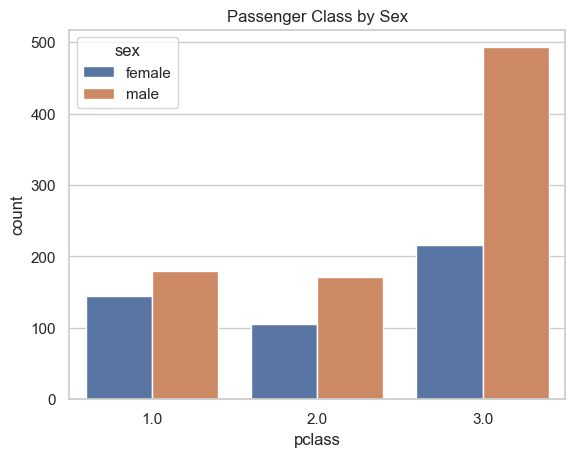

In [87]:
sns.countplot(data=titanic, x="pclass", hue="sex")
plt.title("Passenger Class by Sex")
plt.show()

#### Task

Plot a count of incidents per AnimalClass.

Create a barplot showing the average incident cost (IncidentNominalCost(£)) per TypeOfIncident.

Repeat the barplot but add a hue="AnimalClass" to compare mammals, birds, reptiles, and fish.

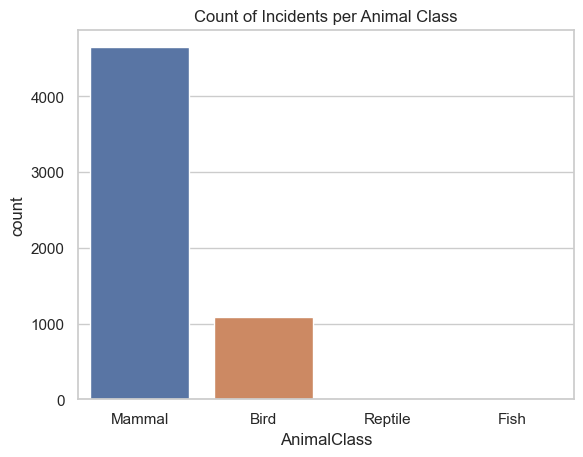

In [ ]:
# Answer
sns.countplot(data=animals, x="AnimalClass", hue="AnimalClass")
plt.title("Count of Incidents per Animal Class")
plt.show()

### B) Distribution Plots
- Histplot

- KDE overlay

- Split by hue

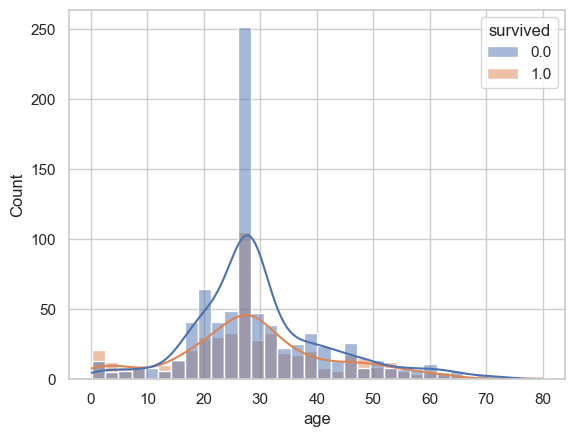

In [96]:
sns.histplot(data=titanic, x="age", hue="survived", kde=True)
plt.show()

### Task
Plot the distribution of PumpHoursTotal.

In [107]:
animals.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5752 entries, 0 to 5751
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   IncidentNumber              5752 non-null   object 
 1   DateTimeOfCall              5752 non-null   object 
 2   CalYear                     5752 non-null   int64  
 3   FinYear                     5752 non-null   object 
 4   TypeOfIncident              5752 non-null   object 
 5   PumpCount                   5716 non-null   float64
 6   PumpHoursTotal              5752 non-null   float64
 7   HourlyNominalCost(£)        5752 non-null   int64  
 8   IncidentNominalCost(£)      5716 non-null   float64
 9   FinalDescription            5749 non-null   object 
 10  AnimalGroupParent           5752 non-null   object 
 11  PropertyType                5752 non-null   object 
 12  SpecialServiceTypeCategory  5752 non-null   object 
 13  SpecialServiceType          5752 

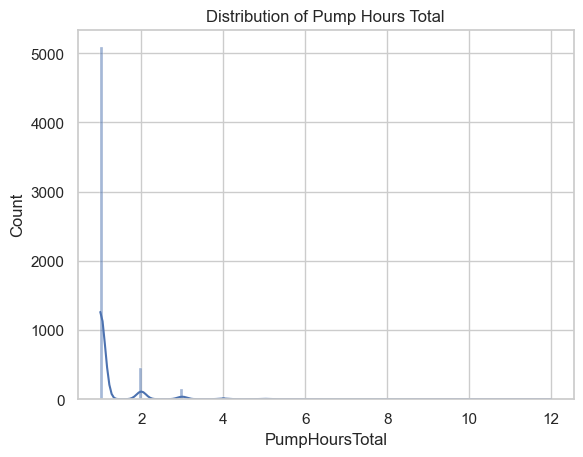

In [109]:
sns.histplot(data=animals, x="PumpHoursTotal", kde=True)
plt.title("Distribution of Pump Hours Total")
plt.show()

### C) Relationship Plots
- Scatter

- Box

- Violin

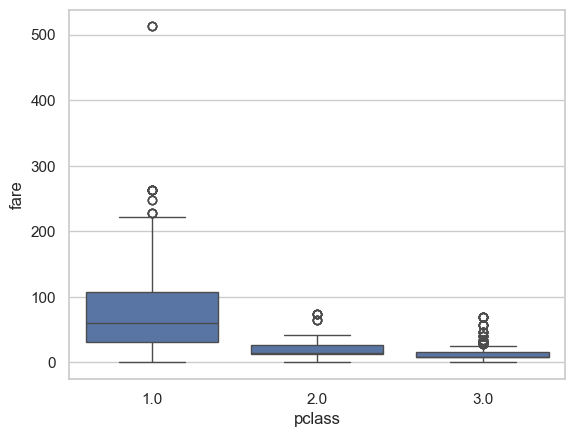

In [99]:
sns.boxplot(data=titanic, x="pclass", y="fare")
plt.show()

#### Tasks

Create a scatterplot of PumpHoursTotal vs IncidentNominalCost(£) coloured by AnimalClass.

Create a boxplot of IncidentNominalCost(£) by AnimalGroupParent.

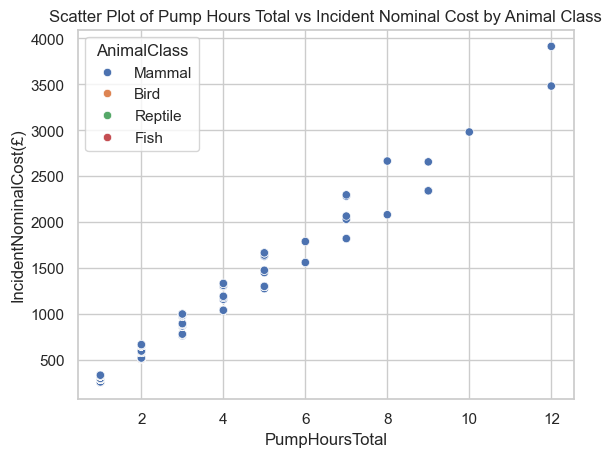

In [103]:
# Create a scatterplot of PumpHoursTotal vs IncidentNominalCost(£) coloured by AnimalClass.
sns.scatterplot(data=animals, x="PumpHoursTotal", y="IncidentNominalCost(£)", hue="AnimalClass")
plt.title("Scatter Plot of Pump Hours Total vs Incident Nominal Cost by Animal Class")
plt.show()

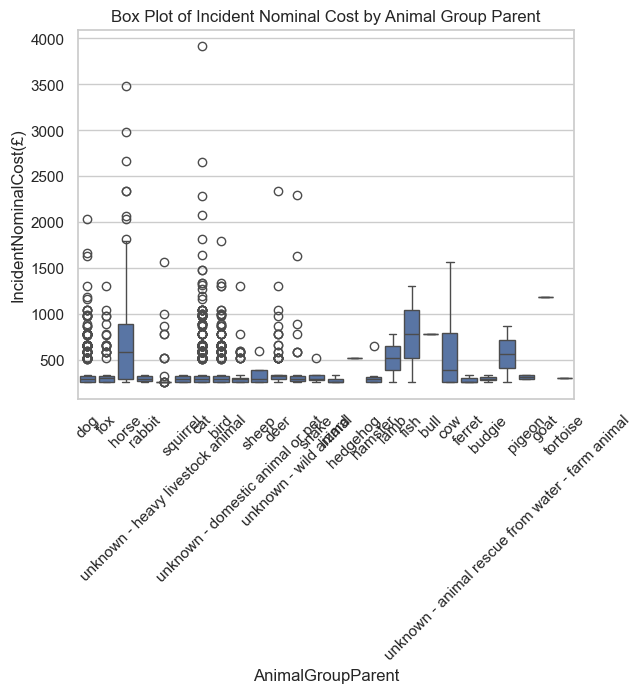

In [ ]:
# Create a boxplot of IncidentNominalCost(£) by AnimalGroupParent.
sns.boxplot(data=animals, x="AnimalGroupParent", y="IncidentNominalCost(£)")
plt.title("Box Plot of Incident Nominal Cost by Animal Group Parent")
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.show()

### D) Correlation Heatmap
Good for quick EDA.

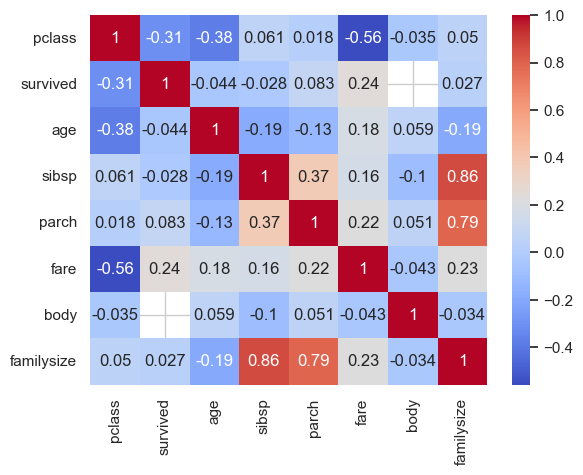

In [105]:
corr = titanic.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

#### Task
Create a correlation heatmap of all numeric columns in the animals dataset.

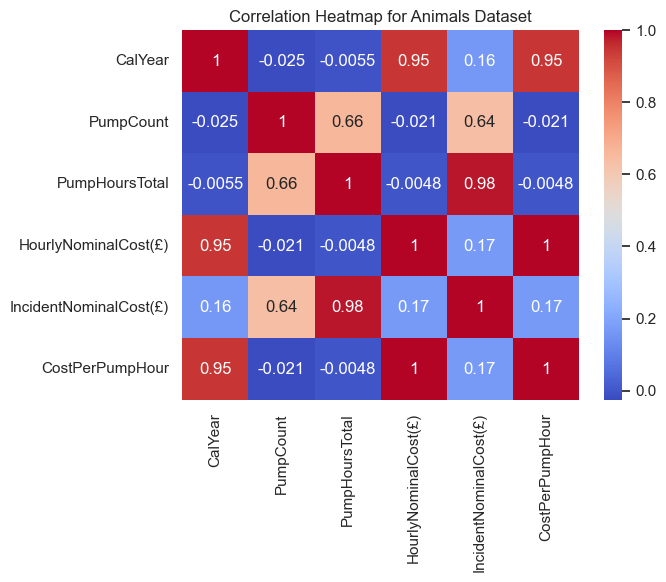

In [106]:
animal_corr = animals.corr(numeric_only=True)
sns.heatmap(animal_corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap for Animals Dataset")
plt.show()